# Phase 06 — Vietnamese Handwriting Crawler & Detector

## Workflow
1. **Search** Vietnamese handwriting images via SerpApi (Google & Pinterest)
2. **Download** and validate images → saves both file path + source URL
3. **Detect** text lines with PaddleOCR
4. **Recognize** text with VietOCR and filter Vietnamese content
5. **Crop** valid line images for training data

## Key Features
- ✅ Stores URL metadata alongside downloaded files
- ✅ Strict Vietnamese text validation (requires diacritics)
- ✅ Length filtering (>50 chars for quality)
- ✅ Comprehensive rejection tracking

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os
import json
import requests
import hashlib
import re
import logging
import random
import time
import torch
from pathlib import Path
from typing import Tuple, List, Dict
from io import BytesIO
from glob import glob

import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
from serpapi import GoogleSearch
import matplotlib.pyplot as plt

# For Pinterest direct crawling
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import TimeoutException, NoSuchElementException
from urllib.parse import quote, urlencode

/home/khang/miniconda3/envs/cv_torch_env/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# ── Configuration ───────────────────────────────────────────────────────────
SERPAPI_KEY = "e98493af257458dc5a5777606e8d4f7f2e8b7b29cac87dfdb3acd3eb175b6109"

# Suppress verbose logging
logging.disable(logging.WARNING)
logging.getLogger("ppocr").setLevel(logging.ERROR)
logging.getLogger("paddle").setLevel(logging.ERROR)

# Setup directory paths
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
CRAWL_DIR = DATA_DIR / "crawled" / "image"
DETECTED_DIR = DATA_DIR / "crawled" / "detected_lines"
DOWNLOADED_DATA_JSON = DATA_DIR / "crawled" / "downloaded_data.json"

# Create directories
CRAWL_DIR.mkdir(parents=True, exist_ok=True)
DETECTED_DIR.mkdir(parents=True, exist_ok=True)

# Search parameters
PINTEREST_IMAGES_PER_PAGE = 500  # Pinterest can handle more
GOOGLE_IMAGES_PER_PAGE = 100     # Google Images standard limit
MIN_IMAGE_SIZE = 100
GOOGLE_PAGES = 2
PINTEREST_PAGES = 10

# Detection parameters
MAX_SIDE = 960
MIN_LINE_H = 10
MIN_LINE_W = 30
MIN_TEXT_LENGTH = 2
MIN_TEXT_LENGTH_FILTER = 45  

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Crawl directory: {CRAWL_DIR}")
print(f"✓ Detected lines directory: {DETECTED_DIR}")
print(f"✓ Downloaded data file: {DOWNLOADED_DATA_JSON}")
print(f"✓ Pinterest: {PINTEREST_IMAGES_PER_PAGE} imgs/page | Google: {GOOGLE_IMAGES_PER_PAGE} imgs/page")
print(f"✓ Min text length filter: {MIN_TEXT_LENGTH_FILTER} chars")

✓ Base directory: /home/khang/Projects/OCR_project/ocr_ai_agent_coding
✓ Crawl directory: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image
✓ Detected lines directory: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/detected_lines
✓ Downloaded data file: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/downloaded_data.json
✓ Pinterest: 500 imgs/page | Google: 100 imgs/page
✓ Min text length filter: 45 chars


## Step 1: Search for Vietnamese Handwriting Images

In [3]:
SEARCH_QUERIES = [
    "viết tay",
    "vở ghi chép bài",
    "font chữ viết tay tiếng việt",
    "chữ viết tay tiếng việt",
    "chữ viết tay học sinh",
    "bài văn viết tay học sinh",
    "trang vở học sinh viết tay kín chữ",
    "trang vở học sinh ghi chép kín trang",
    "bài thi viết tay tiếng việt",
    "đoạn văn dài viết tay tiếng việt",
    "vở học sinh chép bài đầy trang",
    "trang vở ô ly viết tay kín chữ",
]

In [4]:
def get_best_pinterest_urls(url):
    # nếu đã là originals thì dùng luôn
    if "/originals/" in url:
        return [url]

    return [
        re.sub(r"/\d+x/", "/originals/", url),
        re.sub(r"/\d+x/", "/1200x/", url),
        re.sub(r"/\d+x/", "/736x/", url),
        re.sub(r"/\d+x/", "/564x/", url),  
        re.sub(r"/\d+x/", "/474x/", url),  
        re.sub(r"/\d+x/", "/236x/", url),  
    ]

In [5]:
def search(query, pages, pinterest_only=False):
    """Search Google Images for Vietnamese handwriting"""
    results_all = []

    # Use different limits for Pinterest vs Google
    images_per_page = PINTEREST_IMAGES_PER_PAGE if pinterest_only else GOOGLE_IMAGES_PER_PAGE

    for page in range(pages):
        params = {
            "engine": "google_images",
            "q": f"site:pinterest.com {query}" if pinterest_only else query,
            "api_key": SERPAPI_KEY,
            "num": images_per_page,
            "ijn": page,
        }

        results = GoogleSearch(params).get_dict()
        images = results.get("images_results", [])

        for img in images:
            url = img.get("original", "")
            source = img.get("source", "")
            title = img.get("title", "").lower()

            if not url:
                continue
            if pinterest_only:
                if "pinimg.com" not in url:
                    continue

            results_all.append((url, source))

    return results_all

In [11]:
def download_full(url, source):
    """Download image and return metadata including path and URL"""
    candidates = (
        get_best_pinterest_urls(url)
        if "pinimg.com" in url
        else [url]
    )

    for c in candidates:
        try:
            r = requests.get(c, timeout=10)
            if r.status_code != 200 or len(r.content) < 5000:
                continue

            img = Image.open(BytesIO(r.content)).convert("RGB")
            w, h = img.size

            if w < MIN_IMAGE_SIZE or h < MIN_IMAGE_SIZE:
                continue

            fname = hashlib.md5(r.content).hexdigest()[:16] + ".jpg"
            path = str(CRAWL_DIR / fname)

            if not os.path.exists(path):
                img.save(path, "JPEG", quality=95)

            return {
                "path": path,
                "url": url,
                "source": source,
                "downloaded_url": c,
                "size": {"width": w, "height": h}
            }
        except Exception:
            continue

    return None

In [5]:
def normalize_pinimg(url):
    return re.sub(r"/\d+x/", "/", url)

## Pinterest Direct Crawling

Crawl directly from Pinterest search results to get more images beyond SERP API limits.

In [7]:
# Pinterest direct crawling configuration
PINTEREST_SCROLL_COUNT = 50  # Number of times to scroll down
PINTEREST_SCROLL_PAUSE = 3   # Seconds to wait between scrolls
PINTEREST_HEADLESS = True    # Run browser in headless mode

In [8]:
def setup_pinterest_driver(headless=True):
    """Setup Chrome driver for Pinterest scraping"""
    from selenium.webdriver.chrome.service import Service
    from webdriver_manager.chrome import ChromeDriverManager
    import subprocess
    import re
    
    chrome_options = Options()
    
    if headless:
        chrome_options.add_argument('--headless=new')  # Use new headless mode
    
    # Essential arguments to prevent DevToolsActivePort error
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')
    chrome_options.add_argument('--disable-gpu')  # Disable GPU acceleration
    chrome_options.add_argument('--disable-software-rasterizer')
    chrome_options.add_argument('--disable-extensions')
    chrome_options.add_argument('--remote-debugging-port=9222')  # Set debugging port
    chrome_options.add_argument('--window-size=1920,1080')  # Set window size for headless
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    
    # Suppress logging
    chrome_options.add_experimental_option('excludeSwitches', ['enable-logging'])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    
    # Get Chrome version and match ChromeDriver version
    try:
        # Try to get Chrome/Chromium version
        result = subprocess.run(['chromium-browser', '--version'], capture_output=True, text=True)
        if result.returncode != 0:
            result = subprocess.run(['google-chrome', '--version'], capture_output=True, text=True)
        
        version_match = re.search(r'(\d+)\.', result.stdout)
        if version_match:
            chrome_version = version_match.group(1)
            print(f"Detected Chrome version: {chrome_version}")
            # Install matching ChromeDriver version
            service = Service(ChromeDriverManager(driver_version=chrome_version).install())
        else:
            # Fallback: let webdriver_manager auto-detect
            service = Service(ChromeDriverManager().install())
    except Exception as e:
        print(f"Could not detect Chrome version, using auto-detection: {e}")
        # Force fresh download by clearing cache
        service = Service(ChromeDriverManager(cache_valid_range=0).install())
    
    driver = webdriver.Chrome(service=service, options=chrome_options)
    return driver

In [9]:
def crawl_pinterest_direct(query, scroll_count=10):
    """
    Crawl Pinterest search results directly using Selenium
    
    Returns: List of (image_url, pin_url) tuples
    
    Note: If you get 'cannot find Chrome binary' error, install Chrome:
    Ubuntu/Debian: sudo apt install -y chromium-browser chromium-chromedriver
    Or use: bash install_pinterest_crawler.sh
    """
    results = []
    
    # Encode query for URL
    encoded_query = quote(query)
    search_url = f"https://www.pinterest.com/search/pins/?q={encoded_query}"
    
    driver = None
    try:
        driver = setup_pinterest_driver(headless=PINTEREST_HEADLESS)
        driver.get(search_url)
        
        # Wait for initial load
        time.sleep(3)
        
        # Scroll to load more content
        for i in range(scroll_count):
            # Scroll down
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(PINTEREST_SCROLL_PAUSE)
            
            if (i + 1) % 3 == 0:
                print(f"  Scrolled {i+1}/{scroll_count} times...")
        
        # Extract image URLs from page source
        page_source = driver.page_source
        
        # Method 1: Find all pinimg.com URLs in page source
        pinimg_pattern = r'https://i\.pinimg\.com/[^"\s]+\.jpg'
        found_urls = re.findall(pinimg_pattern, page_source)
        
        # Method 2: Extract from img tags
        try:
            img_elements = driver.find_elements(By.TAG_NAME, 'img')
            for img in img_elements:
                try:
                    src = img.get_attribute('src')
                    if src and 'pinimg.com' in src and src.endswith('.jpg'):
                        found_urls.append(src)
                except:
                    continue
        except:
            pass
        
        # Deduplicate and normalize
        seen = set()
        for url in found_urls:
            # Normalize URL (remove size variants)
            normalized = normalize_pinimg(url)
            if normalized not in seen:
                seen.add(normalized)
                results.append((url, search_url))
        
        print(f"  Found {len(results)} unique images")
        
    except Exception as e:
        error_msg = str(e)
        print(f"  ⚠️  Error crawling Pinterest: {error_msg}")
        
        # Provide helpful error messages
        if "cannot find Chrome binary" in error_msg or "chrome not reachable" in error_msg.lower():
            print("\n  💡 Chrome/Chromium is not installed. To fix:")
            print("     1. Run: bash install_pinterest_crawler.sh")
            print("     2. Or manually: sudo apt install -y chromium-browser chromium-chromedriver")
            print("\n  ⚠️  Skipping Pinterest direct crawl. You can still use SERP API method below.\n")
        elif "ChromeDriver" in error_msg:
            print("\n  💡 ChromeDriver issue. Try: pip install --upgrade webdriver-manager selenium\n")
    
    finally:
        if driver:
            try:
                driver.quit()
            except:
                pass
    
    return results

In [ ]:
# Run Pinterest direct crawling
print("\n" + "="*60)
print("🔥 PINTEREST DIRECT CRAWLING")
print("="*60)

# Load existing data to avoid re-downloading
existing_data = []
existing_urls = set()

if DOWNLOADED_DATA_JSON.exists():
    with open(DOWNLOADED_DATA_JSON, "r", encoding="utf-8") as f:
        existing_data = json.load(f)
    
    # Build set of normalized URLs
    for item in existing_data:
        url = item.get("url", "")
        downloaded_url = item.get("downloaded_url", "")
        
        if url:
            key = normalize_pinimg(url) if "pinimg.com" in url else url
            existing_urls.add(key)
        if downloaded_url and downloaded_url != url:
            key = normalize_pinimg(downloaded_url) if "pinimg.com" in downloaded_url else downloaded_url
            existing_urls.add(key)
    
    print(f"✓ Loaded {len(existing_data)} existing images")
    print(f"✓ Existing unique URLs: {len(existing_urls)}")

# Crawl Pinterest direct
pinterest_direct_items = []

for query in SEARCH_QUERIES:
    print(f"\n📌 {query}")
    
    pinterest_results = crawl_pinterest_direct(query, scroll_count=PINTEREST_SCROLL_COUNT)
    pinterest_direct_items.extend(pinterest_results)
    
    # Small delay between queries to avoid rate limiting
    time.sleep(2)

# Deduplicate across all queries
seen = set()
unique_pinterest_items = []

for url, source in pinterest_direct_items:
    key = normalize_pinimg(url)
    if key not in seen:
        seen.add(key)
        unique_pinterest_items.append((url, source))

print(f"\n✓ Total unique Pinterest direct URLs from search: {len(unique_pinterest_items)}")

# Filter out already downloaded URLs
new_pinterest_items = []
skipped_pinterest = 0

for url, source in unique_pinterest_items:
    key = normalize_pinimg(url)
    
    if key in existing_urls:
        skipped_pinterest += 1
    else:
        new_pinterest_items.append((url, source))

print(f"✓ Skipped {skipped_pinterest} already downloaded Pinterest URLs")
print(f"✓ New Pinterest URLs to download: {len(new_pinterest_items)}")



🔥 PINTEREST DIRECT CRAWLING
✓ Loaded 3605 existing images
✓ Existing unique URLs: 5139

📌 viết tay
Detected Chrome version: 146
  Scrolled 3/50 times...
  Scrolled 6/50 times...
  Scrolled 9/50 times...
  Scrolled 12/50 times...
  Scrolled 15/50 times...
  Scrolled 18/50 times...
  Scrolled 21/50 times...
  Scrolled 24/50 times...
  Scrolled 27/50 times...
  Scrolled 30/50 times...
  Scrolled 33/50 times...
  Scrolled 36/50 times...
  Scrolled 39/50 times...
  Scrolled 42/50 times...
  Scrolled 45/50 times...
  Scrolled 48/50 times...
  Found 188 unique images

📌 vở ghi chép bài
Detected Chrome version: 146
  Scrolled 3/50 times...
  Scrolled 6/50 times...
  Scrolled 9/50 times...
  Scrolled 12/50 times...
  Scrolled 15/50 times...
  Scrolled 18/50 times...
  Scrolled 21/50 times...
  Scrolled 24/50 times...
  Scrolled 27/50 times...
  Scrolled 30/50 times...
  Scrolled 33/50 times...
  Scrolled 36/50 times...
  Scrolled 39/50 times...
  Scrolled 42/50 times...
  Scrolled 45/50 times.

NameError: name 'download_full' is not defined

In [12]:
# Download new Pinterest images only
newly_downloaded_pinterest = []

if new_pinterest_items:
    for url, source in tqdm(new_pinterest_items, desc="Downloading new Pinterest"):
        result = download_full(url, source)
        if result:
            newly_downloaded_pinterest.append(result)
    
    print(f"\n✓ Downloaded {len(newly_downloaded_pinterest)} new Pinterest images")
else:
    print(f"\n✓ No new Pinterest images to download")

# Merge with existing data
all_data = existing_data + newly_downloaded_pinterest

# Save merged data to main JSON file
with open(DOWNLOADED_DATA_JSON, "w", encoding="utf-8") as f:
    json.dump(all_data, f, indent=2, ensure_ascii=False)

print(f"\n📊 Summary:")
print(f"  - Existing images: {len(existing_data)}")
print(f"  - Newly downloaded: {len(newly_downloaded_pinterest)}")
print(f"  - Total in database: {len(all_data)}")
print(f"✓ All data saved to: {DOWNLOADED_DATA_JSON}")


✓ Downloaded 2573 new Pinterest images

📊 Summary:
  - Existing images: 3605
  - Newly downloaded: 2573
  - Total in database: 6178
✓ All data saved to: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/downloaded_data.json


## SERP API Crawling (Original Method)

This is the original crawling method using SERP API (already completed with 3605 images).

In [16]:
# Load existing downloaded data to avoid duplicates
existing_data = []
existing_urls = set()

if DOWNLOADED_DATA_JSON.exists():
    with open(DOWNLOADED_DATA_JSON, "r", encoding="utf-8") as f:
        existing_data = json.load(f)
    
    # Build set of normalized URLs already downloaded
    for item in existing_data:
        url = item.get("url", "")
        downloaded_url = item.get("downloaded_url", "")
        
        # Add both original and downloaded URL to check
        if url:
            key = normalize_pinimg(url) if "pinimg.com" in url else url
            existing_urls.add(key)
        if downloaded_url and downloaded_url != url:
            key = normalize_pinimg(downloaded_url) if "pinimg.com" in downloaded_url else downloaded_url
            existing_urls.add(key)
    
    print(f"✓ Loaded {len(existing_data)} existing images")
    print(f"✓ Existing unique URLs: {len(existing_urls)}")
else:
    print("✓ No existing data found, starting fresh")

# Run search and download
all_items = []

for query in SEARCH_QUERIES:
    print(f"\n🔍 {query}")

    g = search(query, GOOGLE_PAGES, False)
    p = search(query, PINTEREST_PAGES, True)

    print(f"  Google: {len(g)} | Pinterest: {len(p)}")
    all_items.extend(g + p)

# Deduplicate within new results
seen = set()
unique_items = []

for url, source in all_items:
    key = normalize_pinimg(url) if "pinimg.com" in url else url

    if key not in seen:
        seen.add(key)
        unique_items.append((url, source))

print(f"\n✓ Total unique URLs from search: {len(unique_items)}")

# Filter out URLs that already exist
new_items = []
skipped_count = 0

for url, source in unique_items:
    key = normalize_pinimg(url) if "pinimg.com" in url else url
    
    if key in existing_urls:
        skipped_count += 1
    else:
        new_items.append((url, source))

print(f"✓ Skipped {skipped_count} already downloaded URLs")
print(f"✓ New URLs to download: {len(new_items)}")

# Prioritize Pinterest
new_items.sort(key=lambda x: 0 if "pinimg.com" in x[0] else 1)

# Download new items only
newly_downloaded = []

if new_items:
    for url, source in tqdm(new_items, desc="Downloading new images"):
        result = download_full(url, source)
        if result:
            newly_downloaded.append(result)
    
    print(f"\n✓ Downloaded {len(newly_downloaded)} new images")
else:
    print("\n✓ No new images to download")

# Merge existing data with newly downloaded
all_downloaded_data = existing_data + newly_downloaded

# Save merged metadata
with open(DOWNLOADED_DATA_JSON, "w", encoding="utf-8") as f:
    json.dump(all_downloaded_data, f, indent=2, ensure_ascii=False)

print(f"✓ Total images in database: {len(all_downloaded_data)}")
print(f"  - Existing: {len(existing_data)}")
print(f"  - Newly added: {len(newly_downloaded)}")
print(f"✓ Metadata saved to: {DOWNLOADED_DATA_JSON}")


🔍 viết tay
  Google: 200 | Pinterest: 166

🔍 vở ghi chép bài
  Google: 200 | Pinterest: 346

🔍 font chữ viết tay tiếng việt
  Google: 200 | Pinterest: 317

🔍 chữ viết tay tiếng việt
  Google: 200 | Pinterest: 300

🔍 chữ viết tay học sinh
  Google: 199 | Pinterest: 289

🔍 bài văn viết tay học sinh
  Google: 200 | Pinterest: 290

🔍 trang vở học sinh viết tay kín chữ
  Google: 200 | Pinterest: 259

🔍 trang vở học sinh ghi chép kín trang
  Google: 200 | Pinterest: 17

🔍 bài thi viết tay tiếng việt
  Google: 200 | Pinterest: 318

🔍 đoạn văn dài viết tay tiếng việt
  Google: 200 | Pinterest: 369

🔍 vở học sinh chép bài đầy trang
  Google: 200 | Pinterest: 59

🔍 trang vở ô ly viết tay kín chữ
  Google: 199 | Pinterest: 27

✓ Total unique URLs: 3881


Downloading:  61%|██████    | 2356/3881 [23:36<14:27,  1.76it/s]  /home/khang/miniconda3/envs/cv_torch_env/lib/python3.11/site-packages/PIL/Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Downloading: 100%|██████████| 3881/3881 [35:55<00:00,  1.80it/s]


✓ Downloaded 3605 images
✓ Metadata saved to: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/downloaded_data.json


## Step 2: Initialize OCR Models

In [3]:
from paddleocr import PaddleOCR
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

# Initialize PaddleOCR for text detection
ocr = PaddleOCR(
    use_angle_cls=False,
    lang="vi",
    use_det=True,
    use_gpu=True,
    use_rec=False,
    det_limit_side_len=MAX_SIDE,
    det_limit_type="max",
    det_db_thresh=0.3,
    det_db_box_thresh=0.2,
    show_log=False,
    enable_mkldnn=True,
    det_db_unclip_ratio=2,
)
print("✓ PaddleOCR detector initialized")

✓ PaddleOCR detector initialized


In [4]:
# Initialize VietOCR for recognition
config = Cfg.load_config_from_name('vgg_transformer')
config['cnn']['pretrained'] = True
config['predictor']['beamsearch'] = True
config['device'] = 'cuda:0'
recognitor = Predictor(config)
print("✓ VietOCR recognizer initialized")

18533it [00:19, 963.76it/s] 


✓ VietOCR recognizer initialized


## Step 3: Helper Functions

In [5]:
def read_and_resize_fast(path: str, max_side: int = MAX_SIDE):
    """Read and resize image efficiently"""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    h, w = img.shape[:2]
    m = max(h, w)
    if m > max_side:
        scale = max_side / m
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    return img


def upscale_if_small(img, min_side=800, max_scale=2.0):
    """Upscale small images for better detection"""
    h, w = img.shape[:2]
    m = max(h, w)
    if m < min_side:
        scale = min(min_side / m, max_scale)
        img = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_CUBIC)
    return img


def sharpen(img):
    """Sharpen image for better OCR"""
    kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(img, -1, kernel)


def safe_ocr(detector, img):
    """Safe OCR with error handling"""
    if detector is None:
        return []
    try:
        result = detector.ocr(img)
    except Exception as e:
        print(f"OCR error: {e}")
        return []
    if not result or result[0] is None:
        return []
    return result[0]

In [6]:
def is_valid_vietnamese_text(text: str, min_length: int = 2) -> bool:
    """Validate Vietnamese text (requires diacritics)"""
    if not text or len(text.strip()) < min_length:
        return False

    text_no_space = text.strip()

    # Check valid character ratio
    VIETNAMESE_CHARS = set(config['vocab'])
    valid_char_count = sum(1 for c in text_no_space if c in VIETNAMESE_CHARS)
    valid_ratio = valid_char_count / len(text_no_space) if len(text_no_space) > 0 else 0

    if valid_ratio < 0.8:
        return False

    # STRICT: Require Vietnamese diacritics
    vietnamese_diacritics = 'àảãáạăằẳẵắặâầẩẫấậèẻẽéẹêềểễếệìỉĩíịòỏõóọôồổỗốộơờởỡớợùủũúụưừửữứựỳỷỹýỵđ'
    has_vietnamese_diacritics = any(c in vietnamese_diacritics for c in text.lower())

    if not has_vietnamese_diacritics:
        return False

    # Filter ALL CAPS English-like text
    letters_only = [c for c in text_no_space if c.isalpha()]
    if letters_only:
        uppercase_ratio = sum(1 for c in letters_only if c.isupper()) / len(letters_only)
        if uppercase_ratio > 0.9 and not has_vietnamese_diacritics:
            return False

    return True

In [7]:
def order_points(pts):
    """Order 4 points clockwise from top-left"""
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect


def crop_rotated(img, box):
    """Crop rotated bounding box using perspective transform"""
    box = box.astype("float32")
    w1 = np.linalg.norm(box[0] - box[1])
    w2 = np.linalg.norm(box[2] - box[3])
    width = int(max(w1, w2))

    h1 = np.linalg.norm(box[0] - box[3])
    h2 = np.linalg.norm(box[1] - box[2])
    height = int(max(h1, h2))

    if width <= 0 or height <= 0:
        return None

    dst = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype="float32")
    M = cv2.getPerspectiveTransform(box, dst)
    warped = cv2.warpPerspective(img, M, (width, height))
    return warped

## Step 4: Text Detection & Cropping

In [8]:
def crop_text_lines_with_recognition(
    image_path: str,
    detector,
    recognitor,
    out_dir: str,
    min_line_h: int = MIN_LINE_H,
    min_line_w: int = MIN_LINE_W,
    max_side: int = MAX_SIDE,
    min_text_length: int = MIN_TEXT_LENGTH,
    min_text_length_filter: int = MIN_TEXT_LENGTH_FILTER,
    batch_size: int = 32
):
    """Detect, recognize, and crop valid Vietnamese text lines with batch processing"""
    img = read_and_resize_fast(image_path, max_side)
    if img is None:
        return [], [], []

    img = upscale_if_small(img, min_side=800)
    img = sharpen(img)

    lines = safe_ocr(detector, img)
    if len(lines) == 0:
        return [], [], []

    dt_polys = [np.array(r[0], dtype=np.float32) for r in lines]
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    valid_crops = []
    rejected_crops = []
    recognition_results = []
    fname_base = Path(image_path).stem

    # Prepare all crops first
    cropped_images = []
    valid_boxes = []
    box_indices = []
    
    for i, box in enumerate(dt_polys):
        try:
            box = order_points(box)
            cropped_img = crop_rotated(img, box)

            if cropped_img is None or cropped_img.size == 0:
                rejected_crops.append({'reason': 'empty_crop', 'box': box.tolist()})
                continue

            h, w = cropped_img.shape[:2]

            if h < min_line_h or w < min_line_w:
                rejected_crops.append({'reason': 'too_small', 'box': box.tolist()})
                continue

            # Auto-rotate if vertical
            if h > w:
                cropped_img = cv2.rotate(cropped_img, cv2.ROTATE_90_CLOCKWISE)
                h, w = cropped_img.shape[:2]

            # Add padding
            pad = 2
            cropped_img = cv2.copyMakeBorder(cropped_img, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[255, 255, 255])

            # Resize for VietOCR
            target_h = 32
            ratio = cropped_img.shape[1] / cropped_img.shape[0]
            target_w = int(target_h * ratio)

            if target_w <= 0:
                rejected_crops.append({'reason': 'invalid_resize', 'box': box.tolist()})
                continue

            cropped_img = cv2.resize(cropped_img, (target_w, target_h))
            cropped_pil = Image.fromarray(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))

            # Store for batch processing
            cropped_images.append((cropped_img, cropped_pil))
            valid_boxes.append(box)
            box_indices.append(i)

        except Exception as e:
            rejected_crops.append({'reason': f'error: {str(e)}', 'box': box.tolist() if isinstance(box, np.ndarray) else None})
            continue

    # Batch recognition
    if len(cropped_images) > 0:
        # Process in batches
        for batch_start in range(0, len(cropped_images), batch_size):
            batch_end = min(batch_start + batch_size, len(cropped_images))
            batch_pil_images = [img[1] for img in cropped_images[batch_start:batch_end]]
            
            # Batch predict
            recognized_texts = recognitor.predict_batch(batch_pil_images)
            
            # Process results
            for batch_idx, recognized_text in enumerate(recognized_texts):
                global_idx = batch_start + batch_idx
                cropped_img, cropped_pil = cropped_images[global_idx]
                box = valid_boxes[global_idx]
                i = box_indices[global_idx]
                
                is_valid = is_valid_vietnamese_text(recognized_text, min_text_length)
                text_length = len(recognized_text.strip())
                passes_length_filter = text_length > min_text_length_filter

                recognition_results.append({
                    'text': recognized_text,
                    'text_length': text_length,
                    'is_valid': is_valid,
                    'passes_length_filter': passes_length_filter,
                    'box': box.tolist()
                })

                if not is_valid:
                    rejected_crops.append({
                        'reason': 'invalid_vietnamese',
                        'text': recognized_text,
                        'text_length': text_length,
                        'box': box.tolist()
                    })
                    continue

                if not passes_length_filter:
                    rejected_crops.append({
                        'reason': f'text_too_short (length={text_length}, required>{min_text_length_filter})',
                        'text': recognized_text,
                        'text_length': text_length,
                        'box': box.tolist()
                    })
                    continue

                # Save valid crop
                crop_fname = f"{fname_base}_line{i:03d}.jpg"
                crop_path = os.path.join(out_dir, crop_fname)
                cv2.imwrite(crop_path, cropped_img)
                valid_crops.append(crop_path)

    return valid_crops, rejected_crops, recognition_results


## Step 5: Load Downloaded Data

In [9]:
# Load downloaded data with URL metadata
with open(DOWNLOADED_DATA_JSON, "r") as f:
    downloaded_data = json.load(f)

downloaded_paths = [item["path"] for item in downloaded_data]
print(f"✓ Loaded {len(downloaded_paths)} downloaded images")
print(f"✓ Each image has: path, url, source, size metadata")

✓ Loaded 6178 downloaded images
✓ Each image has: path, url, source, size metadata


## Step 6: Test Detection (Visual)

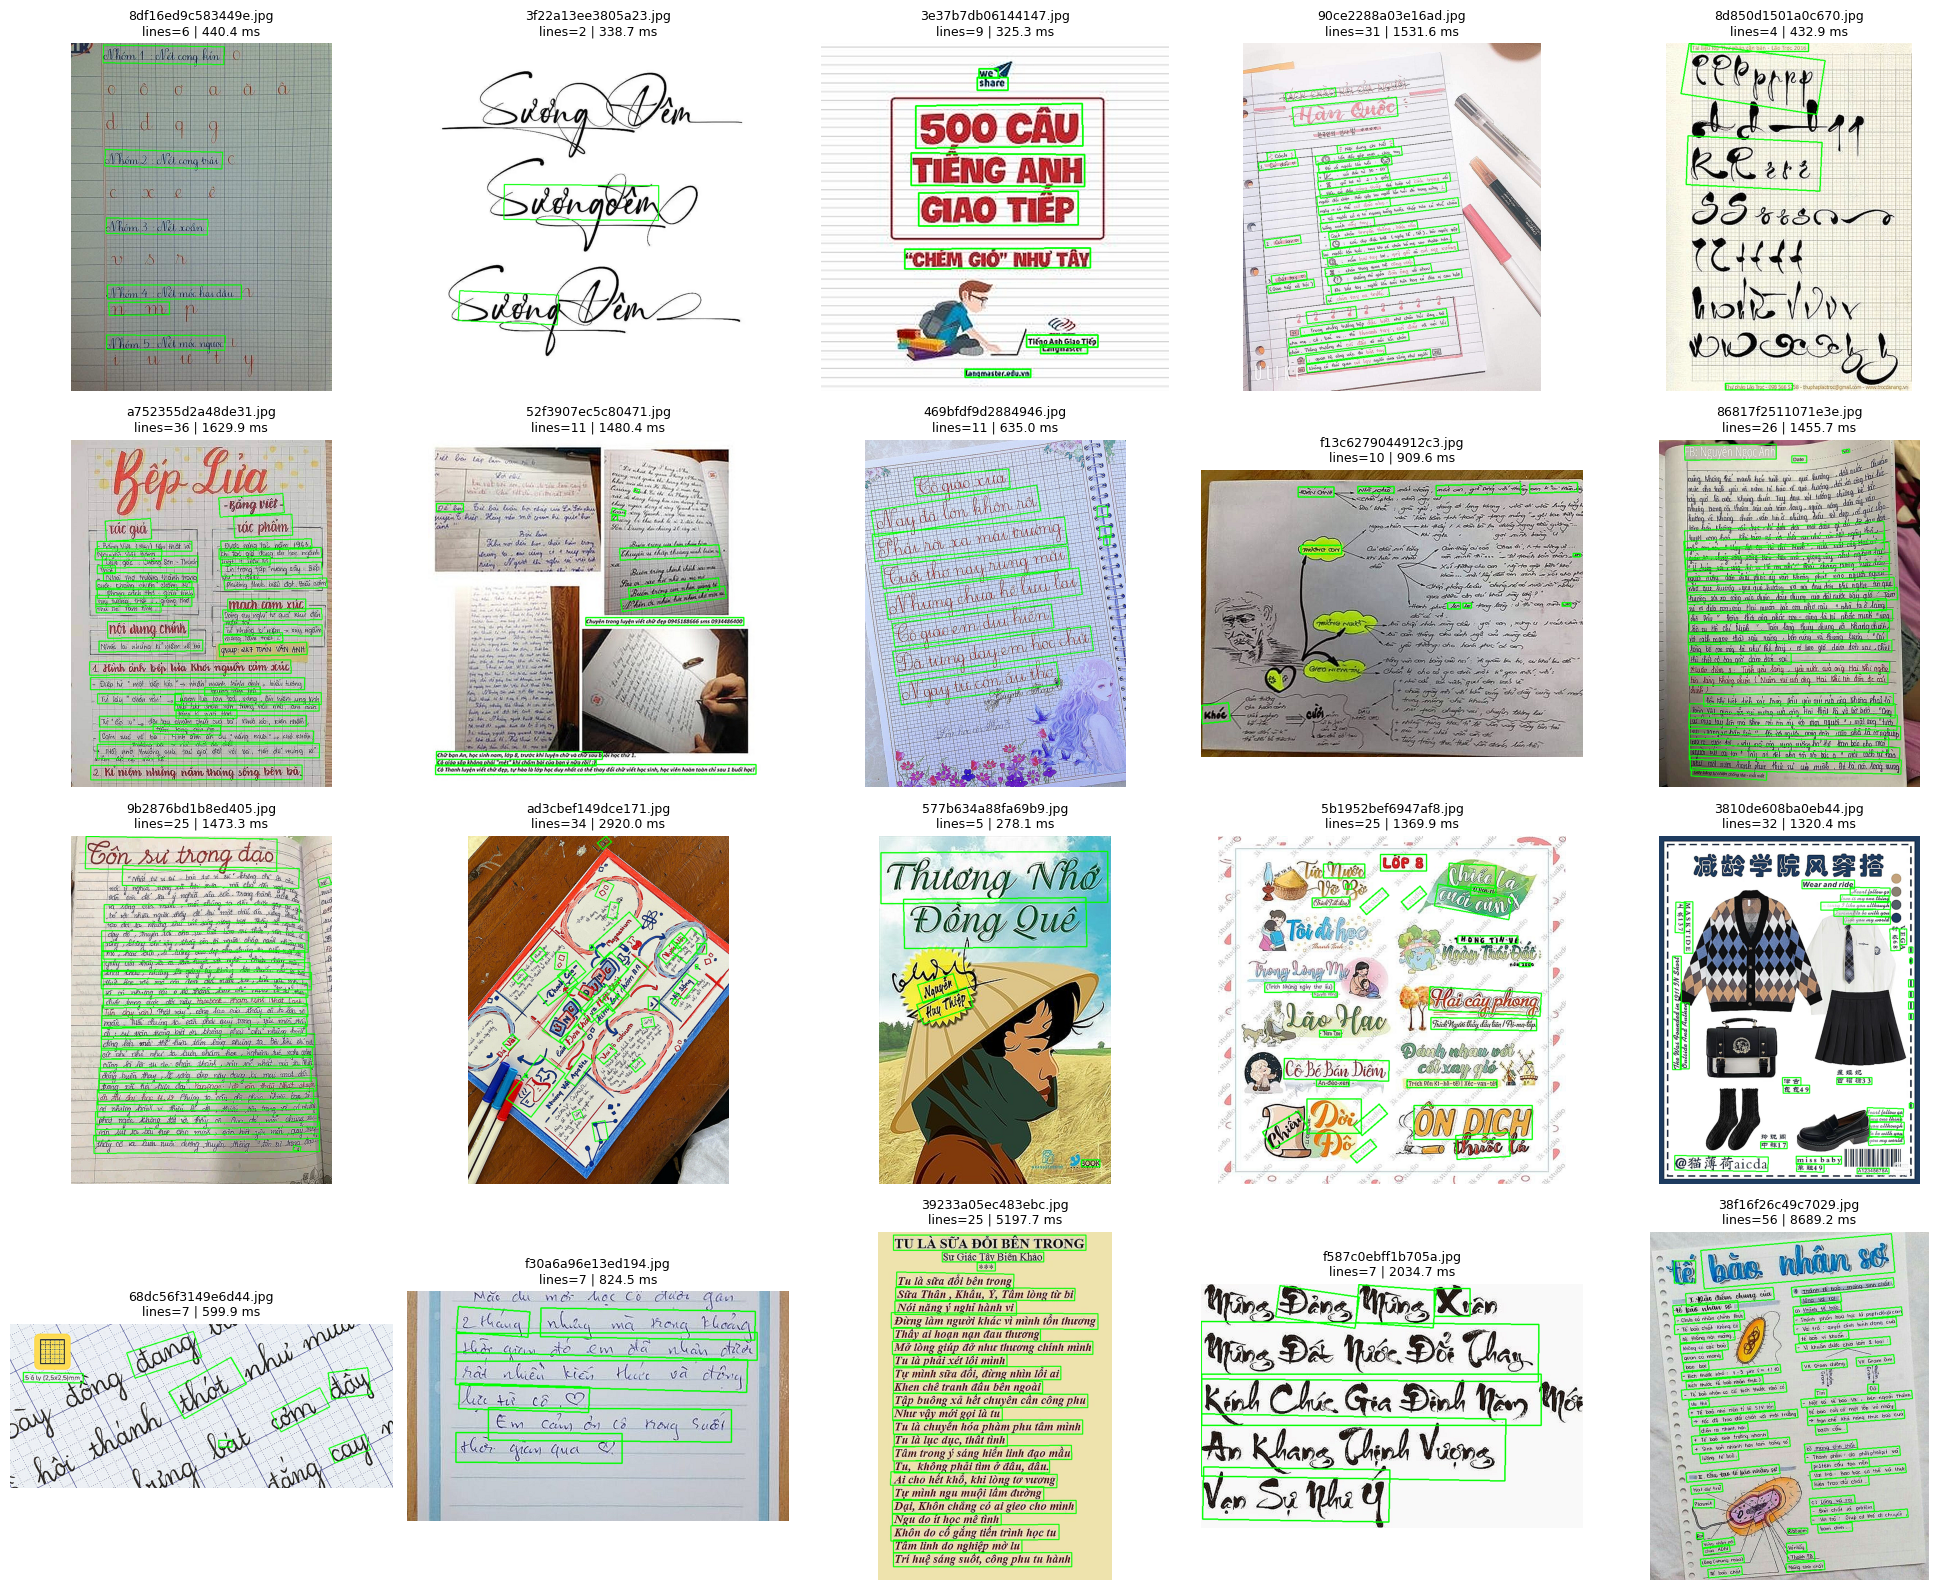


✓ Avg detect time: 1694.4 ms/image
✓ Min/Max: 278.1 / 8689.2 ms


In [10]:
# Test on random sample
N_SHOW = 20
SEED = 70

rng = random.Random(SEED)
sample_paths = rng.sample(downloaded_paths, min(N_SHOW, len(downloaded_paths)))

# Warm-up
if sample_paths:
    warm_img = read_and_resize_fast(sample_paths[0], MAX_SIDE)
    if warm_img is not None:
        warm_img = upscale_if_small(warm_img)
        warm_img = sharpen(warm_img)
        _ = ocr.ocr(warm_img)

vis_items = []
times = []

for p in sample_paths:
    img = read_and_resize_fast(p, MAX_SIDE)
    if img is None:
        continue

    img = upscale_if_small(img)
    img = sharpen(img)

    t0 = time.perf_counter()
    result = ocr.ocr(img)
    dt = time.perf_counter() - t0
    times.append(dt)

    vis = img.copy()
    lines = result[0] if result and result[0] is not None else []
    n_lines = len(lines)

    if lines:
        for line in lines:
            if line is None:
                continue
            box = np.array(line[0], dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(vis, [box], True, (0, 255, 0), 2)

    vis_items.append((Path(p).name, vis, n_lines, dt))

# Visualize
n = len(vis_items)
cols = 5
rows = (n + cols - 1) // cols

plt.figure(figsize=(20, 4 * rows))

for i, (name, vis, n_lines, dt) in enumerate(vis_items, 1):
    ax = plt.subplot(rows, cols, i)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}\nlines={n_lines} | {dt*1000:.1f} ms", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

if times:
    print(f"\n✓ Avg detect time: {np.mean(times)*1000:.1f} ms/image")
    print(f"✓ Min/Max: {np.min(times)*1000:.1f} / {np.max(times)*1000:.1f} ms")

In [11]:
sample_paths

['/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/8df16ed9c583449e.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/3f22a13ee3805a23.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/3e37b7db06144147.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/90ce2288a03e16ad.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/8d850d1501a0c670.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/a752355d2a48de31.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/52f3907ec5c80471.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/469bfdf9d2884946.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/f13c6279044912c3.jpg',
 '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/86817f2511071e3e.jpg',
 '/home/khang/Projects/OCR_pro

In [12]:
target_path = str(CRAWL_DIR / "86817f2511071e3e.jpg")

img = read_and_resize_fast(target_path, MAX_SIDE)
if img is None:
  print(f"Không đọc được ảnh: {target_path}")
else:
  img = upscale_if_small(img)
  img = sharpen(img)

  lines = safe_ocr(ocr, img)
  print(f"Ảnh: {target_path}")
  print(f"Số bbox detect được: {len(lines)}")

  for i, line in enumerate(lines, 1):
    box = np.array(line[0], dtype=np.float32)
    box = order_points(box)  # [top-left, top-right, bottom-right, bottom-left]
    print(f"BBox {i:03d}: {box.tolist()}")

Ảnh: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/86817f2511071e3e.jpg
Số bbox detect được: 26
BBox 001: [[70.0, 17.0], [323.0, 14.0], [323.0, 55.0], [71.0, 58.0]]
BBox 002: [[505.0, 30.0], [525.0, 27.0], [526.0, 36.0], [506.0, 39.0]]
BBox 003: [[366.0, 46.0], [407.0, 46.0], [407.0, 65.0], [366.0, 65.0]]
BBox 004: [[70.0, 253.0], [620.0, 227.0], [623.0, 278.0], [72.0, 304.0]]
BBox 005: [[68.0, 282.0], [620.0, 259.0], [621.0, 305.0], [70.0, 328.0]]
BBox 006: [[70.0, 307.0], [634.0, 285.0], [636.0, 337.0], [72.0, 359.0]]
BBox 007: [[73.0, 332.0], [634.0, 317.0], [636.0, 365.0], [75.0, 380.0]]
BBox 008: [[73.0, 366.0], [633.0, 350.0], [635.0, 389.0], [74.0, 405.0]]
BBox 009: [[75.0, 394.0], [648.0, 381.0], [649.0, 417.0], [76.0, 430.0]]
BBox 010: [[77.0, 423.0], [657.0, 410.0], [658.0, 443.0], [78.0, 456.0]]
BBox 011: [[79.0, 449.0], [627.0, 440.0], [627.0, 473.0], [79.0, 482.0]]
BBox 012: [[82.0, 477.0], [644.0, 470.0], [644.0, 501.0], [82.0, 508.0]]
BBox 013: 

Testing crop_text_lines on: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/86817f2511071e3e.jpg
Successfully created 19 crops.
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line003.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line004.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line005.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line006.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line007.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line009.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line010.jpg
 - /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output/86817f2511071e3e_line011.jpg
 - /home/khang/Projects/OCR_proj

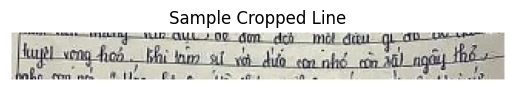

In [13]:
test_path = '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/image/86817f2511071e3e.jpg'
TEST_OUT_DIR = '/home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/test_output'

if os.path.exists(test_path):
    print(f'Testing crop_text_lines on: {test_path}')
    valid_crops, rejected_crops, recognition_results = crop_text_lines_with_recognition(test_path, ocr, recognitor, TEST_OUT_DIR)

    print(f'Successfully created {len(valid_crops)} crops.')
    for c in valid_crops:
        print(f' - {c}')
    
    # Debug: Show rejection reasons
    print(f'\nRejected: {len(rejected_crops)} crops')
    from collections import Counter
    rejection_reasons = Counter([r['reason'] for r in rejected_crops])
    print('Rejection breakdown:')
    for reason, count in rejection_reasons.most_common():
        print(f'  - {reason}: {count}')
    
    # Show a few examples of each rejection type
    print('\nExample rejections:')
    shown_reasons = set()
    for r in rejected_crops[:10]:
        reason = r['reason']
        if reason not in shown_reasons:
            print(f"  [{reason}]", end='')
            if 'text' in r:
                print(f" Text: '{r['text']}' (len={r.get('text_length', 'N/A')})")
            else:
                print()
            shown_reasons.add(reason)

    if valid_crops: # Changed 'crops' to 'valid_crops'
        import matplotlib.pyplot as plt
        sample_crop = cv2.imread(valid_crops[0]) # Changed 'crops' to 'valid_crops'
        plt.imshow(cv2.cvtColor(sample_crop, cv2.COLOR_BGR2RGB))
        plt.title('Sample Cropped Line')
        plt.axis('off')
        plt.show()
else:
    print(f'File not found at {test_path}')

## Step 7: Process All Images

In [14]:
# # Optional: Clear checkpoint to start fresh
# # Uncomment the line below if you want to restart processing from scratch

# CHECKPOINT_FILE = DATA_DIR / "processing_checkpoint.pkl"
# if CHECKPOINT_FILE.exists():
#     CHECKPOINT_FILE.unlink()
#     print("🗑️  Checkpoint cleared. Will start fresh.")
# else:
#     print("ℹ️  No checkpoint found.")

In [15]:
import pickle
from pathlib import Path

# Configuration for checkpoint
CHECKPOINT_FILE = DATA_DIR / "processing_checkpoint.pkl"
CHECKPOINT_INTERVAL = 50  # Save checkpoint every N images

# Initialize or load from checkpoint
if CHECKPOINT_FILE.exists():
    print("📂 Loading checkpoint...")
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint = pickle.load(f)
    
    all_valid_crops = checkpoint['all_valid_crops']
    all_rejected_info = checkpoint['all_rejected_info']
    all_recognition_results = checkpoint['all_recognition_results']
    failed_images = checkpoint['failed_images']
    start_idx = checkpoint['last_processed_idx'] + 1
    
    print(f"✓ Resuming from image {start_idx}/{len(downloaded_paths)}")
    print(f"  - Valid crops so far: {len(all_valid_crops)}")
    print(f"  - Failed images: {len(failed_images)}")
else:
    print("🆕 Starting fresh processing...")
    all_valid_crops = []
    all_rejected_info = []
    all_recognition_results = []
    failed_images = []
    start_idx = 0

print(f"Processing {len(downloaded_paths)} images (starting from index {start_idx})...")

for idx, img_path in enumerate(tqdm(downloaded_paths[start_idx:], 
                                     desc="Detecting & recognizing", 
                                     initial=start_idx, 
                                     total=len(downloaded_paths))):
    actual_idx = start_idx + idx
    
    try:
        valid_crops, rejected_crops, recognition_results = crop_text_lines_with_recognition(
            img_path,
            ocr,
            recognitor,
            str(DETECTED_DIR),
            min_text_length=MIN_TEXT_LENGTH,
            min_text_length_filter=MIN_TEXT_LENGTH_FILTER
        )

        all_valid_crops.extend(valid_crops)

        if rejected_crops:
            all_rejected_info.append({'image': img_path, 'rejected_crops': rejected_crops})

        if recognition_results:
            all_recognition_results.append({'image': img_path, 'results': recognition_results})

        if not valid_crops:
            failed_images.append(img_path)

    except Exception as e:
        print(f"\n⚠ Error: {img_path}: {str(e)}")
        failed_images.append(img_path)
    
    # Save checkpoint periodically
    if (actual_idx + 1) % CHECKPOINT_INTERVAL == 0:
        checkpoint = {
            'all_valid_crops': all_valid_crops,
            'all_rejected_info': all_rejected_info,
            'all_recognition_results': all_recognition_results,
            'failed_images': failed_images,
            'last_processed_idx': actual_idx
        }
        with open(CHECKPOINT_FILE, 'wb') as f:
            pickle.dump(checkpoint, f)
        print(f"\n💾 Checkpoint saved at image {actual_idx + 1}/{len(downloaded_paths)}")

# Save final checkpoint
checkpoint = {
    'all_valid_crops': all_valid_crops,
    'all_rejected_info': all_rejected_info,
    'all_recognition_results': all_recognition_results,
    'failed_images': failed_images,
    'last_processed_idx': len(downloaded_paths) - 1
}
with open(CHECKPOINT_FILE, 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"\n✓ Valid Vietnamese lines: {len(all_valid_crops)}")
print(f"✓ Processed images: {len(downloaded_paths)}")
print(f"✗ Failed: {len(failed_images)}")
print(f"✗ Rejected crops: {sum(len(info['rejected_crops']) for info in all_rejected_info)}")
print(f"\n💾 Final checkpoint saved to {CHECKPOINT_FILE}")



📂 Loading checkpoint...
✓ Resuming from image 5000/6178
  - Valid crops so far: 8012
  - Failed images: 3806
Processing 6178 images (starting from index 5000)...


Detecting & recognizing:  82%|████████▏ | 5050/6178 [06:08<2:14:12,  7.14s/it]


💾 Checkpoint saved at image 5050/6178


Detecting & recognizing:  83%|████████▎ | 5100/6178 [10:46<1:25:46,  4.77s/it]


💾 Checkpoint saved at image 5100/6178


...


💾 Checkpoint saved at image 6100/6178


Detecting & recognizing: 100%|█████████▉| 6150/6178 [1:33:10<00:40,  1.46s/it]


💾 Checkpoint saved at image 6150/6178


Detecting & recognizing: 100%|██████████| 6178/6178 [1:33:43<00:00,  4.77s/it]



✓ Valid Vietnamese lines: 12134
✓ Processed images: 6178
✗ Failed: 4589
✗ Rejected crops: 114053

💾 Final checkpoint saved to /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/processing_checkpoint.pkl


## Step 8: Save Results

In [16]:
# Save valid crop paths
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
detected_image_paths = []
detected_image_paths = []

for ext in image_extensions:
    detected_image_paths.extend(glob(str(DETECTED_DIR / ext)))

detected_image_paths = sorted(detected_image_paths)

output_json = DETECTED_DIR / "valid_line_crops.json"
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(detected_image_paths, f, indent=2, ensure_ascii=False)

print(f"✓ Saved {len(detected_image_paths)} cropped lines to {output_json}")

✓ Saved 9187 cropped lines to /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/detected_lines/valid_line_crops.json


## Step 9: Verify Integrity

In [17]:
# Verify downloaded files
with open(DOWNLOADED_DATA_JSON, "r") as f:
    downloaded_data = json.load(f)

saved_paths = [item["path"] for item in downloaded_data]

img_exts = ["*.jpg", "*.jpeg", "*.png", "*.bmp"]
actual_files = []
for ext in img_exts:
    actual_files.extend(CRAWL_DIR.glob(ext))
actual_files = set(str(p.resolve()) for p in actual_files)

missing_files = [p for p in saved_paths if not Path(p).exists()]

print(f"✓ Files in metadata: {len(saved_paths)}")
print(f"✓ Actual files: {len(actual_files)}")
print(f"{'✓' if len(missing_files) == 0 else '✗'} Missing: {len(missing_files)}")

if missing_files:
    print(f"⚠ Examples: {missing_files[:5]}")

✓ Files in metadata: 6178
✓ Actual files: 4991
✓ Missing: 0
